In [ ]:
from __future__ import annotations

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

# -------------------- UMAP (supervised) --------------------
# Requires: pip install umap-learn
try:
    import umap
except Exception as e:
    raise ImportError(
        "This script requires umap-learn.\n"
        "Install it with: pip install umap-learn"
    ) from e

# fastcluster is optional but faster for linkage (not used here, but kept in case you extend)
try:
    import fastcluster  # noqa: F401
    _HAVE_FASTCLUSTER = True
except Exception:
    _HAVE_FASTCLUSTER = False


# ============================= USER SETTINGS =============================
dt_folder = Path(r"J:\project_trainingAggression\Data")

# ---- Mouse groups ----
Agg = ["975826", "975827", "975833", "978772", "988590", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978774", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]  # 978775 mounts/light attacks on last day
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

all_mice = Agg + nonAgg + maladaptive

# FR settings
dtFR = 1.0  # seconds
taus = [2.0]               # smoothing time constants (seconds)
tau_index_for_z = 0        # which tau to z-score and feed to UMAP

# Behavior timeline (fixed 1200 s total)
behavSeq = [
    "InitialBaseline", "Milk", "Break", "Urine", "Break",
    "Anticipation", "Fight", "RedLight", "Urine", "Break",
    "Milk", "FinalBaseline"
]
epochDurSec = [45, 75, 30, 105, 30, 60, 60 * 5, 60 * 5, 105, 30, 75, 45]
TOTAL_SEC = int(sum(epochDurSec))  # 1200

# ---- Segment for embedding ----
# requested: 5.45 min to 15.45 min
SEG_START_MIN = 0
SEG_END_MIN = 20

# Optional downsample (seconds) to reduce dimensionality/noise
DOWNSAMPLE_SEC = 1  # set to 1 to disable

# Output figure
SAVE_FIG = False
out_png = dt_folder / "SUPERVISED_UMAP_5p45_to_15p45min_units.png"


# ============================= HELPERS ==================================
def find_mouse_id(path: Path, ids: list[str]) -> str | None:
    """
    Find a mouse id in a path.
    Matches mid as its own number token (not embedded in longer digit sequences).
    Works for segments like 'mouse978513', 'm978513', etc.
    """
    s = str(path)
    for mid in ids:
        if re.search(rf"(?<!\d){re.escape(mid)}(?!\d)", s):
            return mid
    return None


def find_obs_id(path: Path) -> str | None:
    """Extract obs label (obs1..obs6) from any part of the path."""
    m = re.search(r"(?i)(obs[1-6])", str(path))
    return m.group(1).lower() if m else None


def group_of_mouse(mid: str) -> str:
    """Return canonical group label. Hard fail if mouse isn't in any list."""
    if mid in Agg:
        return "Aggressor"
    if mid in nonAgg:
        return "Non-aggressor"
    if mid in maladaptive:
        return "Maladaptive"
    raise ValueError(f"Mouse id {mid} not found in Agg/nonAgg/maladaptive lists.")


def find_ks_dir(sorter_output_dir: Path) -> Path | None:
    """Find the folder that actually contains spike_clusters.npy etc."""
    if (sorter_output_dir / "spike_clusters.npy").exists():
        return sorter_output_dir

    for cand in ["kilosort4", "kilosort3", "kilosort2", "kilosort"]:
        p = sorter_output_dir / cand
        if (p / "spike_clusters.npy").exists():
            return p

    hits = list(sorter_output_dir.rglob("spike_clusters.npy"))
    if hits:
        return hits[0].parent

    return None


def find_spike_seconds_file(base_dir: Path) -> Path | None:
    """Locate spike_seconds_imec* (exported seconds file)."""
    hits = list(base_dir.rglob("spike_seconds_imec*"))
    return hits[0] if hits else None


def load_good_cluster_ids(clusterInfoPath: Path) -> np.ndarray:
    """Return sorted unique cluster_ids with group == 'good' (case/space tolerant)."""
    if not clusterInfoPath.exists():
        raise FileNotFoundError(f"cluster_info.tsv not found: {clusterInfoPath}")

    cluInfo = pd.read_csv(clusterInfoPath, sep="\t")
    if "cluster_id" not in cluInfo.columns:
        raise RuntimeError("cluster_info.tsv must contain 'cluster_id' column.")
    if "group" not in cluInfo.columns:
        raise RuntimeError("cluster_info.tsv must contain 'group' column.")

    grp = (
        cluInfo["group"]
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("unsorted")
        .to_numpy()
    )

    good = cluInfo.loc[grp == "good", "cluster_id"].to_numpy(dtype=np.int64)
    return np.unique(good)


def butterlow1(wc: float):
    wc = float(np.clip(wc, 1e-3, 0.999))
    b, a = butter(1, wc, btype="low", analog=False, output="ba")
    return b, a


def zscore_rows(x: np.ndarray) -> np.ndarray:
    mu = np.nanmean(x, axis=1, keepdims=True)
    sd = np.nanstd(x, axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    return (x - mu) / sd


def downsample_time(x: np.ndarray, ds_bins: int) -> np.ndarray:
    """
    Downsample along time by averaging non-overlapping bins.
    x: (n_units, n_time)
    """
    if ds_bins <= 1:
        return x
    T = x.shape[1] - (x.shape[1] % ds_bins)
    if T <= 0:
        raise ValueError("Downsampling would remove all time bins.")
    return x[:, :T].reshape(x.shape[0], T // ds_bins, ds_bins).mean(axis=2)


# ============================= DISCOVER SESSIONS =========================
obs_allowed = {f"obs{i}" for i in range(1, 7)}

# Discover sessions via cluster_info.tsv anchor
cluster_info_hits = list(dt_folder.rglob("cluster_info.tsv"))

phyPathList: list[Path] = []
for ci in cluster_info_hits:
    # expected: ...\sorter_output\autoForNeuroConcat\cluster_info.tsv
    if ci.parent.name != "autoForNeuroConcat":
        continue

    sorter_out = ci.parent.parent  # ...\sorter_output

    mid = find_mouse_id(sorter_out, all_mice)
    if mid is None:
        continue

    obs = find_obs_id(sorter_out)
    if obs is None or obs not in obs_allowed:
        continue

    phyPathList.append(sorter_out)

phyPathList = sorted(set(phyPathList))

if not phyPathList:
    print(f"Found {len(cluster_info_hits)} cluster_info.tsv files total under {dt_folder}")
    for ex in cluster_info_hits[:10]:
        print("  example:", ex)
    raise RuntimeError("No sessions found for your mice in obs1..obs6 using cluster_info.tsv discovery.")

print(f"Found {len(phyPathList)} sessions across {len(all_mice)} mice (obs1..obs6).")


# ============================= LOAD + BIN ALL GOOD UNITS =================
edges = np.arange(0, TOTAL_SEC + dtFR, dtFR, dtype=np.float32)
nBins = edges.size - 1

FR_all: list[np.ndarray] = []
unit_group: list[str] = []
unit_mouse: list[str] = []
unit_obs: list[str] = []

for sorter_out in phyPathList:
    mid = find_mouse_id(sorter_out, all_mice)
    if mid is None:
        continue

    obs = find_obs_id(sorter_out)
    if obs is None or obs not in obs_allowed:
        continue

    try:
        grp = group_of_mouse(mid)
    except Exception as e:
        print(f"[WARN] {e} | skipping: {sorter_out}")
        continue

    ks_dir = find_ks_dir(sorter_out)
    if ks_dir is None:
        print(f"[WARN] Could not find KS folder inside: {sorter_out}")
        continue

    clusterInfoPath = sorter_out / "autoForNeuroConcat" / "cluster_info.tsv"

    try:
        good_ids = load_good_cluster_ids(clusterInfoPath)
    except Exception as e:
        print(f"[WARN] {e} | skipping: {sorter_out}")
        continue

    if good_ids.size == 0:
        print(f"[WARN] No GOOD clusters in: {clusterInfoPath} | skipping session")
        continue

    spike_clusters = np.load(ks_dir / "spike_clusters.npy").astype(np.int64).ravel()

    sec_path = find_spike_seconds_file(sorter_out) or find_spike_seconds_file(ks_dir)
    if sec_path is None:
        print(f"[WARN] Could not find spike_seconds_imec* under: {sorter_out} (or {ks_dir})")
        continue

    spikeSec = np.load(sec_path).astype(np.float64).ravel()

    if spikeSec.shape[0] != spike_clusters.shape[0]:
        print(f"[WARN] spikeSec and spike_clusters length mismatch for {sorter_out} | skipping")
        continue

    keep_time = (spikeSec >= 0.0) & (spikeSec < float(TOTAL_SEC))
    keep_good = np.isin(spike_clusters, good_ids)
    keep = keep_time & keep_good

    spikeSec = spikeSec[keep]
    spike_clusters = spike_clusters[keep]

    if spike_clusters.size == 0:
        print(f"[WARN] No spikes from GOOD clusters in-window for {mid} | {obs} | {sorter_out}")
        continue

    clu_ids, inv = np.unique(spike_clusters, return_inverse=True)
    nUnits = clu_ids.size
    if nUnits == 0:
        continue

    bin_idx = (spikeSec / dtFR).astype(np.int64)
    bin_idx = np.clip(bin_idx, 0, nBins - 1)

    counts = np.zeros((nUnits, nBins), dtype=np.float32)
    np.add.at(counts, (inv, bin_idx), 1.0)

    fr = counts / float(dtFR)
    FR_all.append(fr)

    unit_group.extend([grp] * nUnits)
    unit_mouse.extend([mid] * nUnits)
    unit_obs.extend([obs] * nUnits)

    print(f"Loaded {nUnits:4d} GOOD units | {grp:13s} | mouse {mid} | {obs} | {ks_dir}")

if not FR_all:
    raise RuntimeError("No units loaded after filtering for GOOD labels. Check paths + cluster_info.tsv.")

FR_all_mat = np.vstack(FR_all).astype(np.float64)
nTotalUnits = FR_all_mat.shape[0]
print(f"\nTotal GOOD units: {nTotalUnits}, bins per unit: {nBins} (TOTAL_SEC={TOTAL_SEC}s, dtFR={dtFR}s)")


# ============================= SMOOTH ===================================
t_samp = float(dtFR)
FR_smooth = np.zeros((nTotalUnits, nBins, len(taus)), dtype=np.float64)

for k, tau in enumerate(taus):
    wc = t_samp / float(tau)
    b, a = butterlow1(wc)
    FR_smooth[:, :, k] = filtfilt(b, a, FR_all_mat, axis=1)

# z-score by unit (row-wise) using chosen tau
frZ = zscore_rows(FR_smooth[:, :, tau_index_for_z])


# ============================= SEGMENT (5.45 to 15.45 min) ===============
t0_sec = float(SEG_START_MIN) * 60.0
t1_sec = float(SEG_END_MIN) * 60.0

i0 = int(np.clip(round(t0_sec / dtFR), 0, nBins - 1))
i1 = int(np.clip(round(t1_sec / dtFR), 1, nBins))

if i1 <= i0:
    raise RuntimeError(f"Bad segment indices: i0={i0}, i1={i1} (dtFR={dtFR})")

X_seg = frZ[:, i0:i1]  # (nUnits, nTimeSegment)

ds_bins = int(max(1, round(DOWNSAMPLE_SEC / dtFR)))
X_feat = downsample_time(X_seg, ds_bins=ds_bins)

print(f"\nSegment: {t0_sec:.1f}s to {t1_sec:.1f}s => bins [{i0}:{i1}) "
      f"({X_seg.shape[1]} bins); downsample={ds_bins} => X_feat={X_feat.shape}")


Found 390 sessions across 26 mice (obs1..obs6).
Loaded   15 GOOD units | Aggressor     | mouse 975826 | obs1 | J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec0\Kilosort4_probe0\sorter_output
Loaded  194 GOOD units | Aggressor     | mouse 975826 | obs1 | J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec1\Kilosort4_probe1\sorter_output
Loaded   78 GOOD units | Aggressor     | mouse 975826 | obs1 | J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec2\Kilosort4_probe2\sorter_output
Loaded   47 GOOD units | Aggressor     | mouse 975826 | obs2 | J:\project_trainingAggression\Data\20250817_mouse975826\Day03\neuralData\catgt_20250818_m975826_obs2_g0\20250818_m975826_obs2_g0_imec0\Kilosort4_probe0\sorter_output
Loaded  262 GOOD units | Aggressor  

c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyError: 'A'

<Figure size 750x650 with 0 Axes>

c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


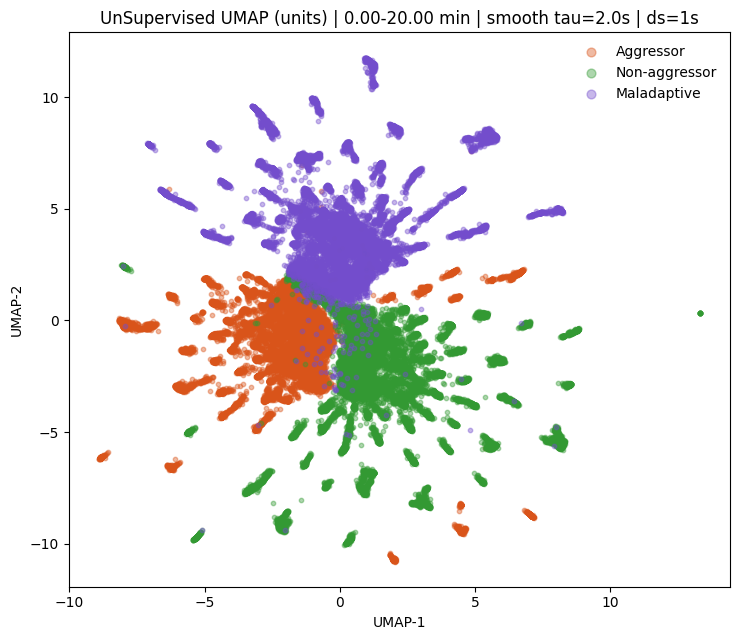

In [29]:
# ============================= UnSUPERVISED UMAP ===========================
# Labels
group_names = ["Aggressor", "Non-aggressor", "Maladaptive"]
allowed = set(group_names)

unit_group_clean = [g.strip() for g in unit_group]
bad = sorted(set(unit_group_clean) - allowed)
if bad:
    print("Group label counts:", Counter(unit_group_clean))
    raise RuntimeError(f"Unexpected group label(s) found: {bad}")

label_to_int = {g: i for i, g in enumerate(group_names)}
y = np.array([label_to_int[g] for g in unit_group_clean], dtype=np.int64)

# UMAP settings
# - metric="correlation" works well for z-scored time series patterns
# - target_metric="categorical" enables supervised UMAP
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.15,
    metric="correlation",
    target_metric="categorical",
    target_weight=0.0,     # 0=unsupervised, 1=strongly supervised
    random_state=0
)

emb = reducer.fit_transform(X_feat, y=y)  # (nUnits, 2)


# ============================= PLOT =====================================
colors = {
    "Aggressor": (0.85, 0.33, 0.10),
    "Non-aggressor": (0.20, 0.60, 0.20),
    "Maladaptive": (0.45, 0.30, 0.80),
}

plt.figure(figsize=(7.5, 6.5))
for g in group_names:
    m = (np.array(unit_group_clean) == g)
    plt.scatter(emb[m, 0], emb[m, 1], s=10, alpha=0.40, label=g, c=[colors[g]])

plt.title(
    f"UnSupervised UMAP (units) | {SEG_START_MIN:.2f}-{SEG_END_MIN:.2f} min "
    f"| smooth tau={taus[tau_index_for_z]}s | ds={ds_bins*dtFR:.0f}s"
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(frameon=False, markerscale=2)
plt.tight_layout()

if SAVE_FIG:
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=300)
    print(f"Saved: {out_png}")

plt.show()

In [9]:
from collections import Counter
print("Units per group:", Counter(unit_group_clean))
print("Units per mouse (top 10):", Counter(unit_mouse).most_common(10))

Units per group: Counter({'Non-aggressor': 19919, 'Maladaptive': 16539, 'Aggressor': 15125})
Units per mouse (top 10): [('1029741', 3318), ('1013590', 3308), ('1034814', 2688), ('997841', 2632), ('997839', 2619), ('1034805', 2583), ('997840', 2505), ('1010832', 2499), ('1029739', 2443), ('1029736', 2295)]


c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Data Analysis\anaconda3\envs\DataAnalysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Data Analysis\an

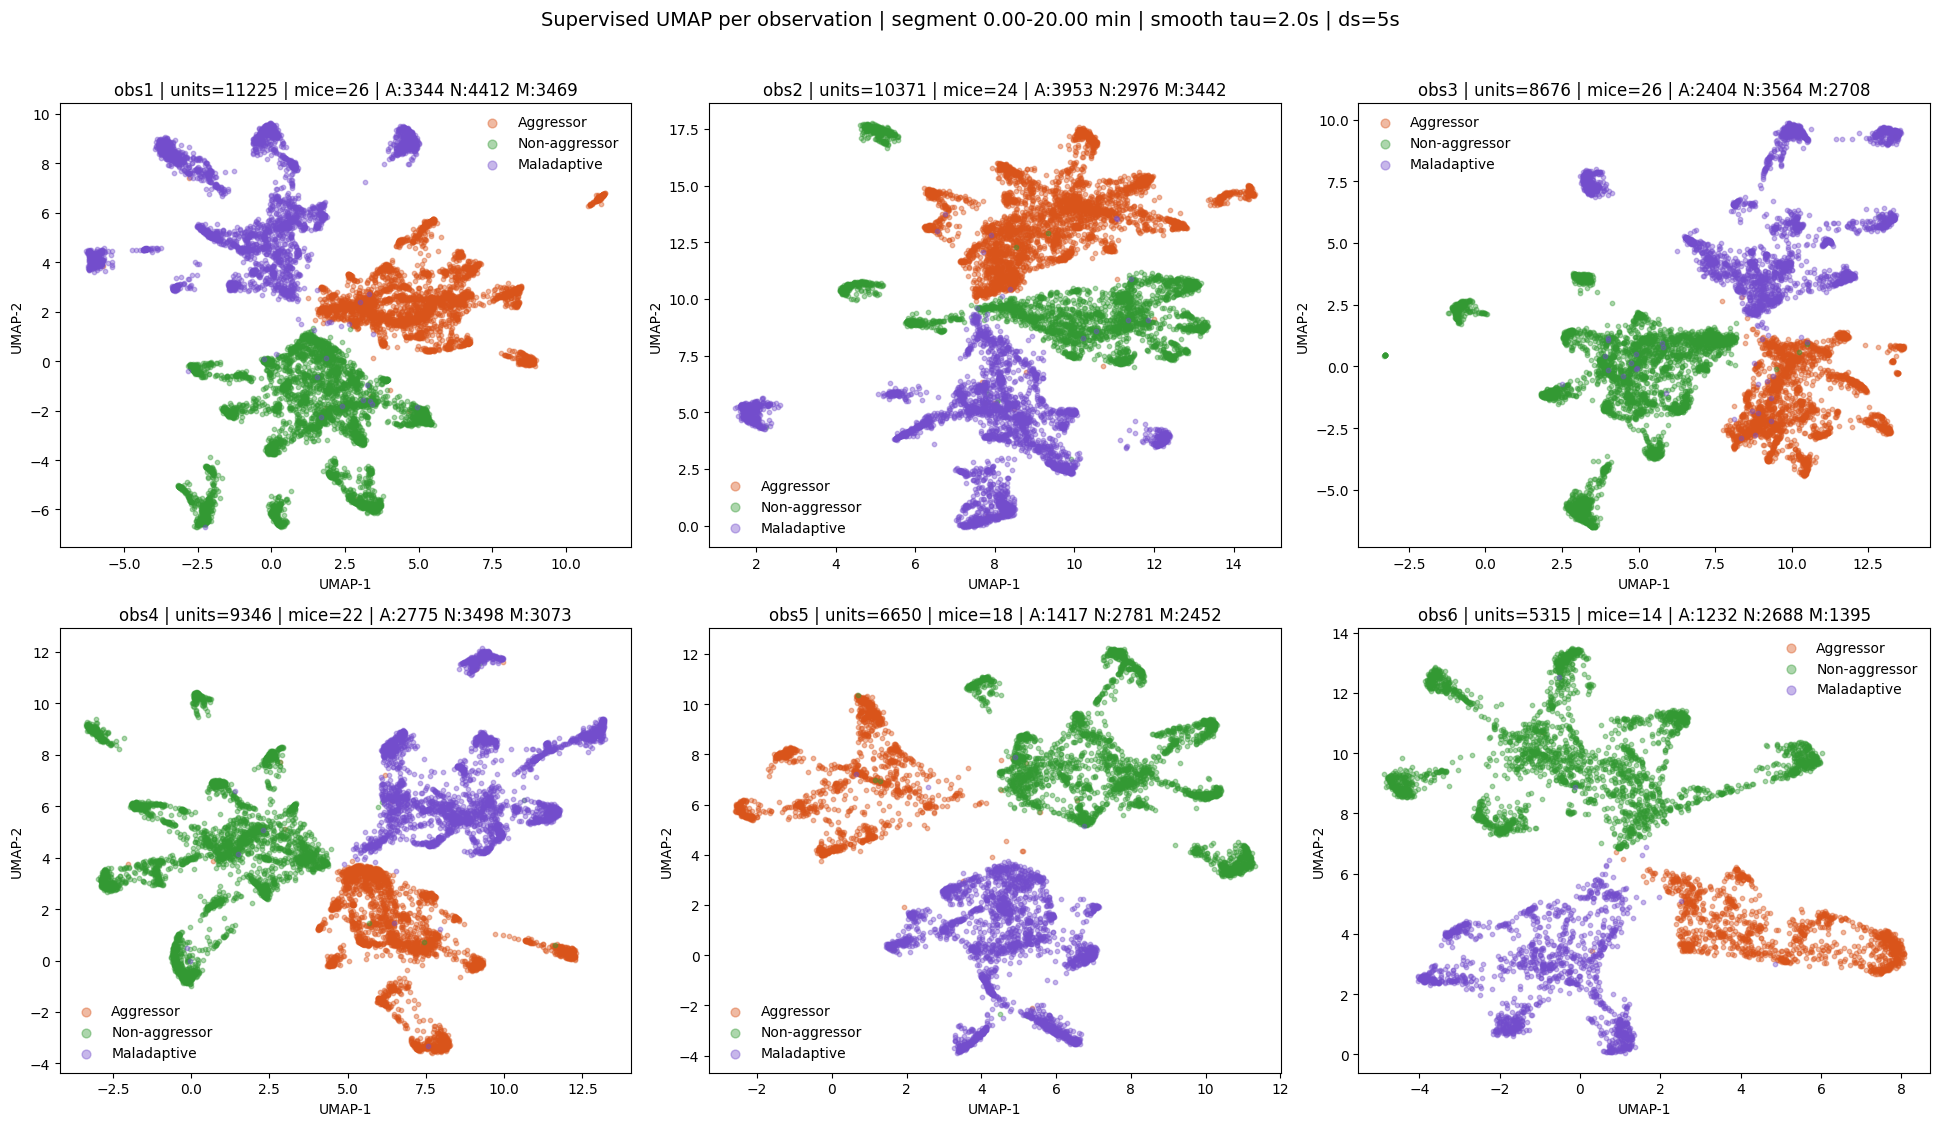

In [10]:
# ============================= UMAP PER OBS ==============================
group_names = ["Aggressor", "Non-aggressor", "Maladaptive"]
allowed = set(group_names)

unit_group_clean = [g.strip() for g in unit_group]
bad = sorted(set(unit_group_clean) - allowed)
if bad:
    print("Group label counts:", Counter(unit_group_clean))
    raise RuntimeError(f"Unexpected group label(s) found: {bad}")

label_to_int = {g: i for i, g in enumerate(group_names)}
y_all = np.array([label_to_int[g] for g in unit_group_clean], dtype=np.int64)

unit_obs_clean = np.array([o.strip().lower() for o in unit_obs])
unit_mouse_arr = np.array(unit_mouse)

# Colormap
colors = {
    "Aggressor": (0.85, 0.33, 0.10),
    "Non-aggressor": (0.20, 0.60, 0.20),
    "Maladaptive": (0.45, 0.30, 0.80),
}

obs_order = [f"obs{i}" for i in range(1, 7)]
present_obs = [o for o in obs_order if o in set(unit_obs_clean)]
if not present_obs:
    raise RuntimeError("No obs labels found in loaded data.")

# --- Choose plotting style: one figure with subplots OR separate figures ---
MAKE_SUBPLOTS = True  # set False for separate figures per obs

if MAKE_SUBPLOTS:
    n = len(present_obs)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(6.5 * ncols, 5.5 * nrows))

for idx_obs, obs_name in enumerate(present_obs, start=1):
    mask = (unit_obs_clean == obs_name)
    Xo = X_feat[mask]
    yo = y_all[mask]
    go = np.array(unit_group_clean)[mask]
    mo = unit_mouse_arr[mask]

    if Xo.shape[0] < 20:
        print(f"[WARN] {obs_name}: only {Xo.shape[0]} units; skipping UMAP.")
        continue

    # Supervised UMAP for this observation only
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.15,
        metric="correlation",
        target_metric="categorical",
        target_weight=0.0,
        random_state=0
    )
    emb = reducer.fit_transform(Xo, y=yo)

    # Plot
    if MAKE_SUBPLOTS:
        ax = plt.subplot(nrows, ncols, idx_obs)
    else:
        plt.figure(figsize=(7.5, 6.5))
        ax = plt.gca()

    for g in group_names:
        mg = (go == g)
        if np.any(mg):
            ax.scatter(
                emb[mg, 0], emb[mg, 1],
                s=10, alpha=0.40, label=g, c=[colors[g]]
            )

    # Useful diagnostics in title
    counts_g = Counter(go)
    n_mice = len(set(mo))
    ax.set_title(
        f"{obs_name} | units={Xo.shape[0]} | mice={n_mice} | "
        f"A:{counts_g.get('Aggressor',0)} N:{counts_g.get('Non-aggressor',0)} M:{counts_g.get('Maladaptive',0)}"
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=False, markerscale=2)

    if not MAKE_SUBPLOTS:
        plt.tight_layout()
        if SAVE_FIG:
            out = dt_folder / f"UNSUPERVISE_UMAP_{obs_name}_{SEG_START_MIN:.2f}_to_{SEG_END_MIN:.2f}min.png"
            plt.savefig(out, dpi=300)
            print(f"Saved: {out}")
        plt.show()

if MAKE_SUBPLOTS:
    plt.suptitle(
        f"Supervised UMAP per observation | segment {SEG_START_MIN:.2f}-{SEG_END_MIN:.2f} min "
        f"| smooth tau={taus[tau_index_for_z]}s | ds={ds_bins*dtFR:.0f}s",
        y=1.02, fontsize=14
    )
    plt.tight_layout()
    if SAVE_FIG:
        out = dt_folder / f"UNSUPERVISE_UMAP_PER_OBS_{SEG_START_MIN:.2f}_to_{SEG_END_MIN:.2f}min.png"
        plt.savefig(out, dpi=300)
        print(f"Saved: {out}")
    plt.show()